# Why Negative Reviews Are Twice as Long

Picture the last time you loved something and the last time something let you down. Which reaction took more words?

On Steam, the answer is unambiguous. A positive review has a median length of **35 characters** — roughly *"great game, highly recommend."* A negative review runs **83 characters**, more than twice as long. The happy player gives a thumbs-up and moves on; the unhappy one stays to write.

The *why* is a more interesting question than the data can answer — so it's worth holding as an open one. A natural reading is that complaint carries a burden of proof that praise doesn't: "I loved it" is a complete review, while "I hated it" invites the question *why?*, and a disappointed reviewer who wants to be believed answers it. But that's interpretation, not evidence. Other explanations fit the same numbers equally well — anger simply produces more words, or complaints name specific failures (a bug, a price, a broken promise) that take space to describe. This chapter establishes the pattern firmly and probes its edges; *which* mechanism produces it is a question for analysis of the review text itself, which this phase deliberately leaves to Phase 4. For now, the gap is worth sitting with: why does disappointment take more words than delight?

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

import _style
_style.set_style()

reviews = pd.read_parquet("../data/processed/reviews.parquet")
reviews["review_len"] = reviews["review"].str.len().fillna(0)

rec = reviews["voted_up"]
print(f"median length — recommended: {reviews.loc[rec,'review_len'].median():.0f} chars")
print(f"median length — not recommended: {reviews.loc[~rec,'review_len'].median():.0f} chars")
print(f"ratio: {reviews.loc[~rec,'review_len'].median() / reviews.loc[rec,'review_len'].median():.1f}x")

median length — recommended: 35 chars
median length — not recommended: 83 chars
ratio: 2.4x


## The gap, and a test that it's real

The median tells the headline — 35 characters versus 83 — but a difference in medians could in principle be a fluke of sampling. With hundreds of thousands of reviews that's unlikely, but we confirm it properly rather than assume it. Because review length is wildly skewed (most reviews are short, a few are essays), we don't lean on means or assume a normal distribution; we use the **Mann-Whitney U test**, which asks a distribution-free question: if you drew one positive and one negative review at random, how often is the negative one longer?

median length — recommended:     35 chars
median length — not recommended: 83 chars  (2.4x)
Mann-Whitney U: p = 0.00e+00
effect size (P[negative longer than positive]): 63.6%


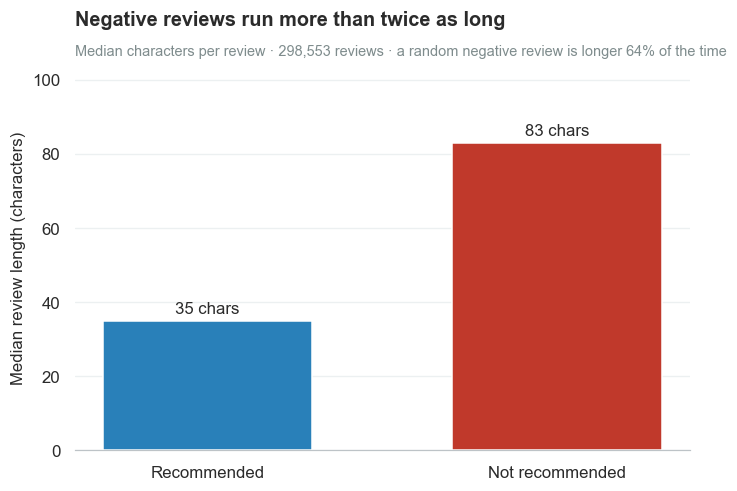

In [2]:
rec = reviews["voted_up"]
pos_len = reviews.loc[rec,  "review_len"]
neg_len = reviews.loc[~rec, "review_len"]

med_pos, med_neg = pos_len.median(), neg_len.median()

# Mann-Whitney U: is the negative-review length stochastically greater?
u, p = mannwhitneyu(neg_len, pos_len, alternative="greater")
# effect size: probability a random negative review is longer than a random positive one
# (rank-biserial / common-language effect size) = U / (n1*n2)
cles = u / (len(neg_len) * len(pos_len))

print(f"median length — recommended:     {med_pos:.0f} chars")
print(f"median length — not recommended: {med_neg:.0f} chars  ({med_neg/med_pos:.1f}x)")
print(f"Mann-Whitney U: p = {p:.2e}")
print(f"effect size (P[negative longer than positive]): {cles:.1%}")

# the contrast, as a clean two-bar chart
fig, ax = plt.subplots(figsize=(7, 4.6))
bars = ax.bar(["Recommended", "Not recommended"], [med_pos, med_neg],
              color=[_style.COUNTER, _style.ACCENT], width=0.6)
ax.bar_label(bars, fmt="%.0f chars", padding=3, fontsize=11)
ax.set_ylabel("Median review length (characters)")
ax.set_ylim(0, med_neg * 1.25)
ax.set_title("Negative reviews run more than twice as long\n", loc="left",
             fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        f"Median characters per review · {len(reviews):,} reviews · "
        f"a random negative review is longer {cles:.0%} of the time",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
plt.show()

## Where the gap lives

A median ratio of 2.4× sounds like a chasm, but the effect size tempers it: a random negative review out-lengths a random positive one 64% of the time, not 90%. The distributions overlap heavily — there are terse pans and sprawling love letters. So the gap isn't that *every* negative review is long. It's that the **very short review is overwhelmingly a positive act** — the one-word verdict, the "10/10", the "great game" — and those one-liners are almost entirely thumbs-up.

     recommended: 38% ultra-short (<20 ch) · 16% long-form (>200 ch)
 not recommended: 21% ultra-short (<20 ch) · 31% long-form (>200 ch)

among ultra-short reviews (<20 ch): 91% are positive
(overall baseline positive rate: 85%)


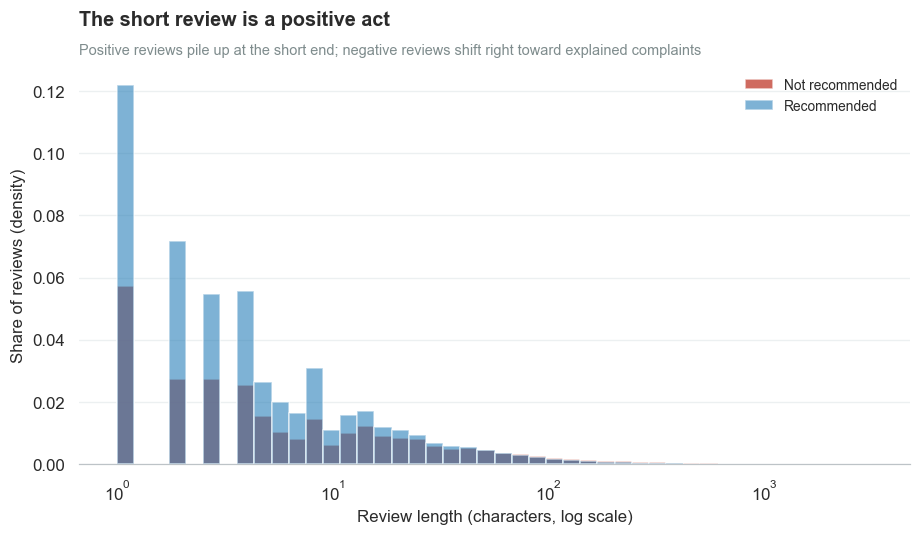

In [3]:
rec = reviews["voted_up"]

# the short-end story, quantified
for label, mask in [("recommended", rec), ("not recommended", ~rec)]:
    s = reviews.loc[mask, "review_len"]
    print(f"{label:>16}: {(s < 20).mean():.0%} ultra-short (<20 ch) · "
          f"{(s > 200).mean():.0%} long-form (>200 ch)")

# and: among ONLY the ultra-short reviews, what share are positive?
ultra = reviews[reviews["review_len"] < 20]
print(f"\namong ultra-short reviews (<20 ch): {ultra['voted_up'].mean():.0%} are positive")
print(f"(overall baseline positive rate: {reviews['voted_up'].mean():.0%})")

# length distribution by sentiment, log scale
fig, ax = plt.subplots(figsize=(8.5, 5))
bins = np.logspace(0, 3.5, 45)
ax.hist(reviews.loc[~rec, "review_len"].clip(1), bins=bins, density=True,
        color=_style.ACCENT, alpha=0.75, label="Not recommended")
ax.hist(reviews.loc[rec, "review_len"].clip(1), bins=bins, density=True,
        color=_style.COUNTER, alpha=0.6, label="Recommended")
ax.set_xscale("log")
ax.set_xlabel("Review length (characters, log scale)")
ax.set_ylabel("Share of reviews (density)")
ax.set_title("The short review is a positive act\n", loc="left", fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        "Positive reviews pile up at the short end; negative reviews shift right toward explained complaints",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
ax.legend(fontsize=9)
plt.show()

## Reading the gap carefully: it lives at the short end

The median ratio (2.4×) and the effect size (64%) seem to disagree — and reconciling them reveals what's actually happening. A tempting reading is that a few furious players write enormous reviews that drag the negative median up. But that can't be it: the median is by construction almost immune to extreme values — a handful of 5,000-character rage-essays move the *mean*, not the *middle* review.

The gap is driven by the opposite end. **It's not that anger produces unusually long reviews — it's that delight produces unusually short ones.** Nearly 40% of positive reviews are one-liners under 20 characters; only half as many negative reviews are. And among those ultra-short reviews, 91% are positive — well above the 85% baseline. "Great game" is a complete positive review; "bad game" apparently doesn't feel like enough. The positive median is low because positivity is comfortable being brief, not because negativity is unusually verbose.

The proof is in what happens when we remove the long tail entirely.

Median length, full data:           pos 35  |  neg 83
Median length, tail capped at p90 (385 ch): pos 35  |  neg 83
  -> capping the long tail barely moves the medians: the gap is NOT the essays.

ultra-short (<20 ch):  pos 38%  |  neg 21%
among <20 ch reviews:  91% are positive  (baseline 85%)


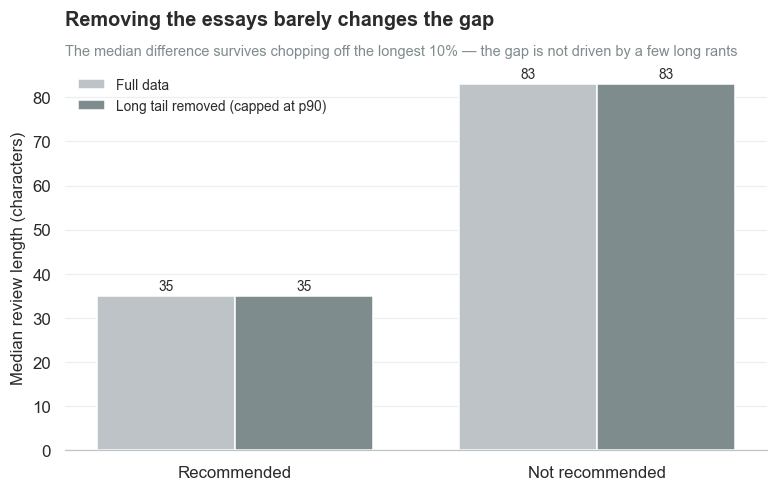

In [ ]:
rec = reviews["voted_up"]

# Recompute medians after capping length at the 90th percentile (chop the essays off).
cap90 = reviews["review_len"].quantile(0.90)
capped = reviews["review_len"].clip(upper=cap90)
print(f"Median length, full data:           pos {reviews.loc[rec,'review_len'].median():.0f}  |  neg {reviews.loc[~rec,'review_len'].median():.0f}")
print(f"Median length, tail capped at p90 ({cap90:.0f} ch): pos {capped[rec].median():.0f}  |  neg {capped[~rec].median():.0f}")
print("  -> capping the long tail barely moves the medians: the gap is NOT the essays.\n")


print(f"ultra-short (<20 ch):  pos {(reviews.loc[rec,'review_len']<20).mean():.0%}  |  neg {(reviews.loc[~rec,'review_len']<20).mean():.0%}")
print(f"among <20 ch reviews:  {reviews.loc[reviews['review_len']<20,'voted_up'].mean():.0%} are positive  (baseline {rec.mean():.0%})")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
x = np.arange(2); w = 0.38
full = [reviews.loc[rec,'review_len'].median(), reviews.loc[~rec,'review_len'].median()]
capd = [capped[rec].median(), capped[~rec].median()]
ax.bar(x - w/2, full, w, label="Full data", color=_style.GREY)
ax.bar(x + w/2, capd, w, label="Long tail removed (capped at p90)", color=_style.GREY_DARK)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Recommended", "Not recommended"])
ax.set_ylabel("Median review length (characters)")
ax.set_title("Removing the essays barely changes the gap\n", loc="left", fontsize=13, fontweight="bold")
ax.text(0, 1.02,
        "The median difference survives chopping off the longest 10% — the gap is not driven by a few long rants",
        transform=ax.transAxes, fontsize=9.5, color=_style.GREY_DARK, va="bottom")
ax.legend(fontsize=9)
plt.show()